# Batch y procesos programados

Este cuaderno es exploratorio: ayuda a descubrir nomenclatura, claves utiles y fallos visibles en procesos batch del cliente.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd()
candidate_roots = [
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == 'notebooks' else NOTEBOOK_CWD,
    NOTEBOOK_CWD / 'observability' / 'd365-fo-observability',
]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'kql_runner.py').exists() and (candidate / 'queries').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('No se pudo localizar observability/d365-fo-observability desde el directorio actual')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from kql_runner import build_client, load_config, load_kql, plot_bar, run_kql

config = load_config()
client = build_client(config=config)
BATCH_DAYS = config['query_days']

In [2]:
df_batch_discovery = run_kql(client, load_kql('50_batch_discovery.kql'), days=BATCH_DAYS, name='Batch discovery', config=config)
df_event_names = run_kql(client, load_kql('53_batch_event_name_discovery.kql'), days=BATCH_DAYS, name='Batch event names', config=config)
display(df_batch_discovery.head(20))
display(df_event_names.head(30))
plot_bar(df_event_names, 'name', 'Count', 'Eventos batch mas frecuentes', top_n=20)

Ejecutando: Batch discovery
Filas devueltas: 0
Ejecutando: Batch event names
Filas devueltas: 0


,name,Count


,name,Count


No hay datos suficientes para dibujar el grafico.


In [3]:
df_dimension_keys = run_kql(client, load_kql('54_batch_dimension_key_discovery.kql'), days=BATCH_DAYS, name='Batch dimension keys', config=config)
display(df_dimension_keys.head(30))
plot_bar(df_dimension_keys, 'DimensionKey', 'KeyOccurrences', 'Dimension keys mas repetidas', top_n=20)

Ejecutando: Batch dimension keys
Filas devueltas: 0


,EventName,DimensionKey,KeyOccurrences


No hay datos suficientes para dibujar el grafico.


Ejecutando: Batch failures
Filas devueltas: 2


,timestamp,BatchJobCaption,ActivityId,ClassName,BatchJobId,BatchTaskId,EventMessage,ExceptionType,ExceptionMessage,CallStack,customDimensions
0,2026-07-07 08:00:08.635933+00:00,PER - FR - Generación de peticiones del SII,08b4b536-0b95-0002-eaa1-ba09950bdd01,PWSIIGenerateRequestController,5637225106,5637367854,Unable to execute batch task.,UpdateConflictException,An unknown exception occurredMicrosoft.Dynamic...,The Exception message is truncated. Please rea...,"{""UserGuid"":""{8D00309F-1F4A-492E-AF5C-0F983CD7..."
1,2026-07-06 08:00:11.503189+00:00,PER - FR - Generación de peticiones del SII,3fd62280-06cc-0002-464b-9940cc06dd01,PWSIIGenerateRequestController,5637225106,5637367854,Unable to execute batch task.,UpdateConflictException,An unknown exception occurredMicrosoft.Dynamic...,The Exception message is truncated. Please rea...,"{""UserGuid"":""{8D00309F-1F4A-492E-AF5C-0F983CD7..."


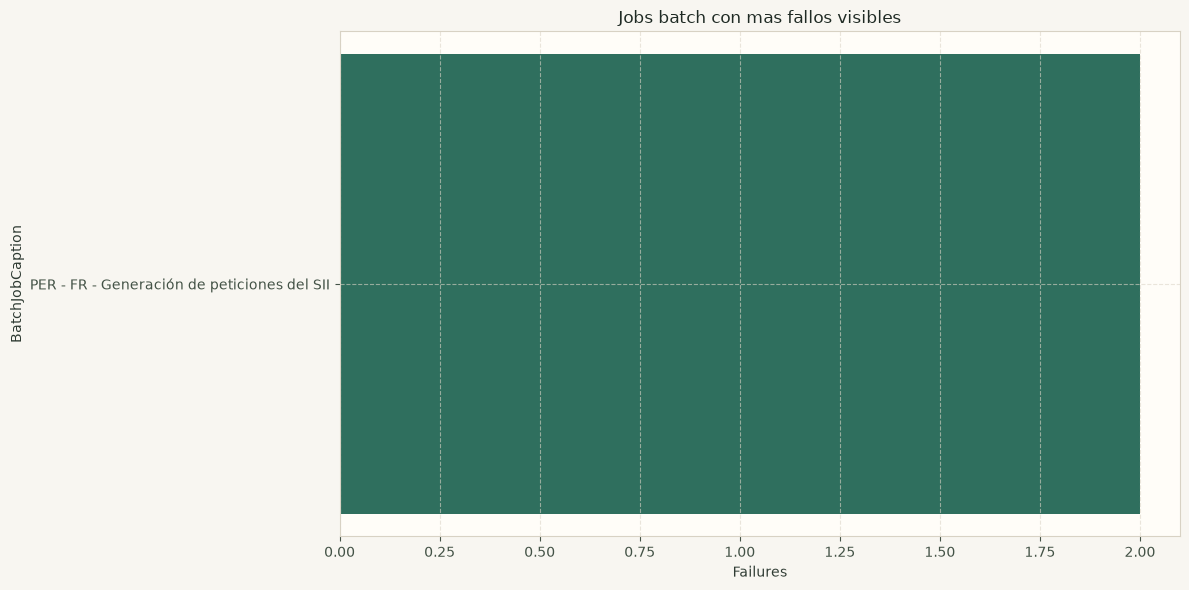

Ejecutando: Batch properties sample
Filas devueltas: 0


,timestamp,name,customDimensions


In [4]:
df_failures = run_kql(client, load_kql('52_batch_failures.kql'), days=BATCH_DAYS, name='Batch failures', config=config)
display(df_failures.head(30))
if not df_failures.empty and 'BatchJobCaption' in df_failures.columns:
    df_failure_counts = df_failures.groupby('BatchJobCaption', dropna=False).size().reset_index(name='Failures')
    plot_bar(df_failure_counts, 'BatchJobCaption', 'Failures', 'Jobs batch con mas fallos visibles', top_n=15)

df_properties = run_kql(client, load_kql('51_batch_properties_sample.kql'), days=BATCH_DAYS, name='Batch properties sample', config=config)
display(df_properties.head(20))

## Uso recomendado

- Este cuaderno es especialmente util en fase de descubrimiento y modelado del dominio batch del cliente.
- No todas las consultas batch deben acabar en dashboard: primero hay que validar que la nomenclatura y las dimension keys son estables.
- Si los fallos se concentran en pocos jobs, un ranking por BatchJobCaption es buena visualizacion candidata.